# Matplotlib Advanced Customization

In [1]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

# Load data
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

# Data cleanup
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df["job_skills"] = df["job_skills"].apply(lambda skill: ast.literal_eval(skill)
                                          if pd.notna(skill) else skill)

c:\Users\PC\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Filter for Data Analyst data
df_DA = df[df["job_title_short"] == "Data Analyst"].copy()

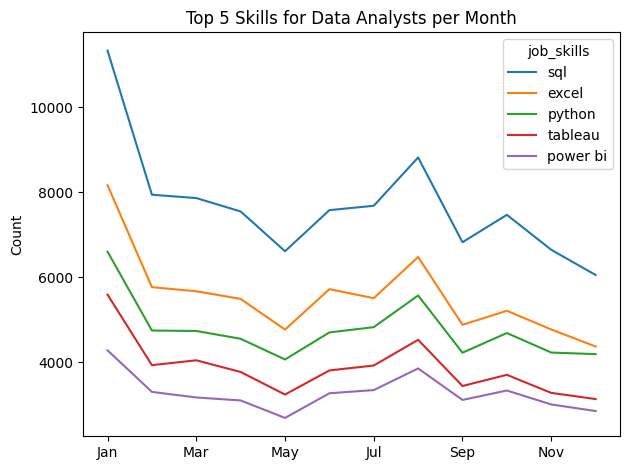

In [3]:
# Create a new column for month number
df_DA["job_posted_month_no"] = df_DA["job_posted_date"].dt.month

# Explode the job_skills column and pivot
df_DA_explode = df_DA.explode("job_skills")
df_DA_pivot = df_DA_explode.pivot_table(index="job_posted_month_no", columns="job_skills", 
                                        aggfunc="size", fill_value=0)

# Sort the skills by count
df_DA_pivot.loc["Total"] = df_DA_pivot.sum()
df_DA_pivot = df_DA_pivot[df_DA_pivot.loc["Total"].sort_values(ascending=False).index]
df_DA_pivot = df_DA_pivot.drop("Total")

# Use month names for plotting
df_DA_pivot = df_DA_pivot.reset_index()
df_DA_pivot["job_posted_month"] = df_DA_pivot["job_posted_month_no"].apply(
    lambda x: pd.to_datetime(x, format="%m").strftime("%b") if pd.notna(x) else x
)
df_DA_pivot = df_DA_pivot.set_index("job_posted_month")
df_DA_pivot = df_DA_pivot.drop(columns="job_posted_month_no")

# Get the top 5 skills
df_DA_pivot.iloc[:, :5].plot(kind="line")
plt.title("Top 5 Skills for Data Analysts per Month")
plt.ylabel("Count")
plt.xlabel("")
plt.tight_layout()
plt.show()

In [4]:
df_DA_pivot

job_skills,sql,excel,python,tableau,power bi,r,sas,powerpoint,word,sap,...,xamarin,mattermost,gtx,esquisse,chainer,capacitor,nuxt.js,msaccess,ovh,suse
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,11336,8170,6606,5596,4285,3607,3830,1880,1778,1251,...,0,0,0,0,0,1,1,0,0,0
Feb,7947,5772,4751,3936,3307,2576,2634,1291,1235,954,...,0,0,0,0,0,0,0,0,0,0
Mar,7868,5675,4741,4051,3176,2650,2554,1266,1203,892,...,1,0,0,0,0,0,0,0,0,1
Apr,7553,5496,4557,3776,3106,2399,2598,1190,1177,947,...,0,0,0,0,0,0,0,0,1,0
May,6617,4773,4070,3245,2695,2093,1940,979,957,851,...,0,0,0,0,0,0,0,1,0,0
Jun,7584,5724,4707,3812,3275,2442,2174,1173,1237,987,...,0,0,0,0,0,0,0,0,0,0
Jul,7687,5513,4831,3928,3350,2444,2118,1096,1069,996,...,0,0,1,0,0,0,0,0,0,0
Aug,8823,6482,5576,4533,3859,2975,2560,1332,1298,1117,...,0,0,0,0,0,0,0,0,0,0
Sep,6829,4886,4229,3446,3118,2146,1880,944,945,852,...,0,1,0,0,0,0,0,0,0,0


## Line plot customization

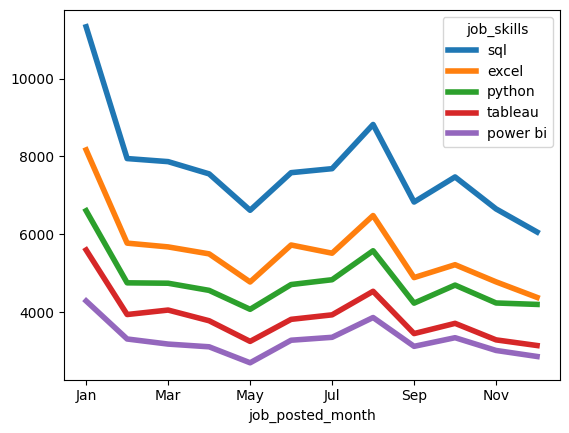

In [5]:
df_DA_pivot.iloc[:, :5].plot(
    kind="line",
    linewidth=4
)
plt.show()

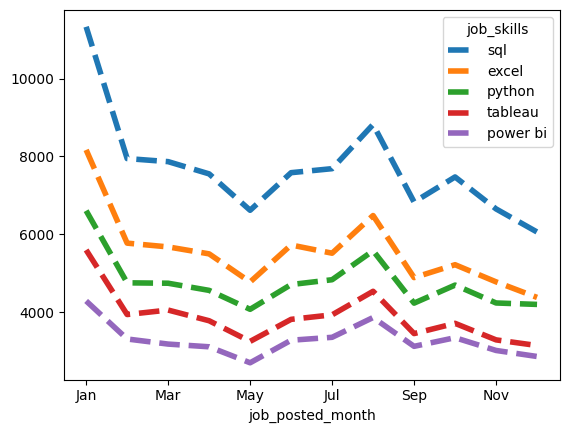

In [11]:
df_DA_pivot.iloc[:, :5].plot(
    kind="line",
    linewidth=4,
    linestyle="--" # options: "-", "--", "-.", ":"
)
plt.show()

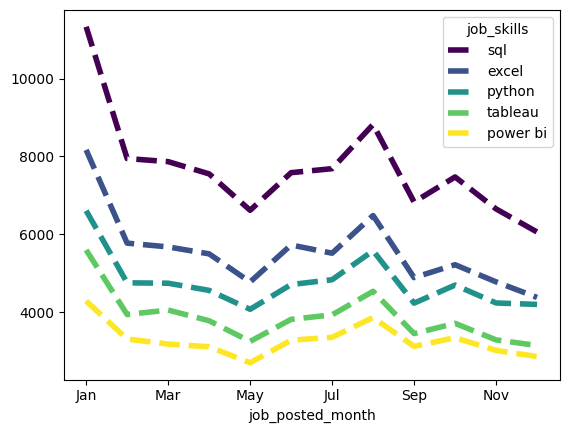

In [21]:
df_DA_pivot.iloc[:, :5].plot(
    kind="line",
    linewidth=4,
    linestyle="--", # options: "-", "--", "-.", ":"
    colormap="viridis" # options: "viridis", "plasma", "inferno", "magma", "cividis"
)
plt.show()

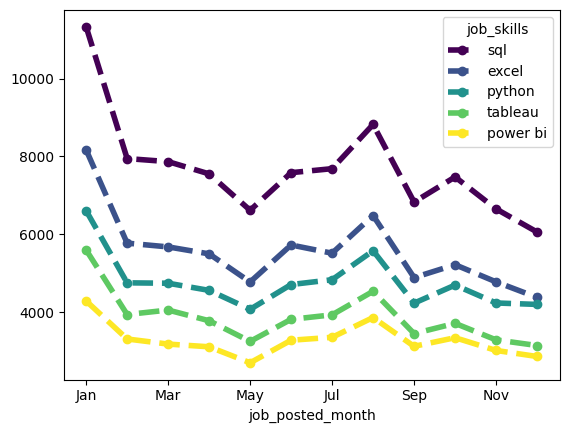

In [25]:
df_DA_pivot.iloc[:, :5].plot(
    kind="line",
    linewidth=4,
    linestyle="--", # options: "-", "--", "-.", ":"
    colormap="viridis", # options: "viridis", "plasma", "inferno", "magma", "cividis"
    marker="o" # options: "o", "x", "+", "*", "s", ",", ".", "1", "2", "3", "4", ...
)
plt.show()

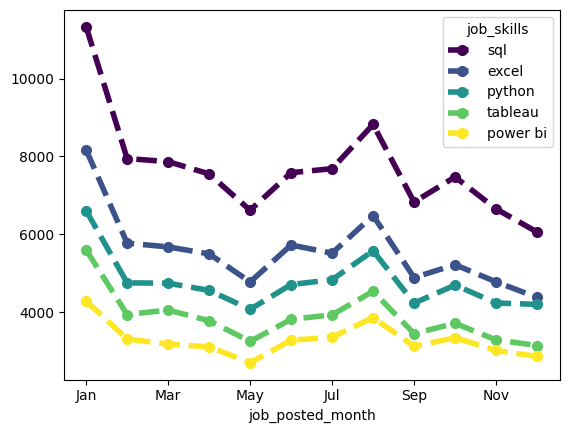

In [28]:
df_DA_pivot.iloc[:, :5].plot(
    kind="line",
    linewidth=4,
    linestyle="--", # options: "-", "--", "-.", ":"
    colormap="viridis", # options: "viridis", "plasma", "inferno", "magma", "cividis"
    marker="o", # options: "o", "x", "+", "*", "s", ",", ".", "1", "2", "3", "4", ...
    markersize=7
)
plt.show()

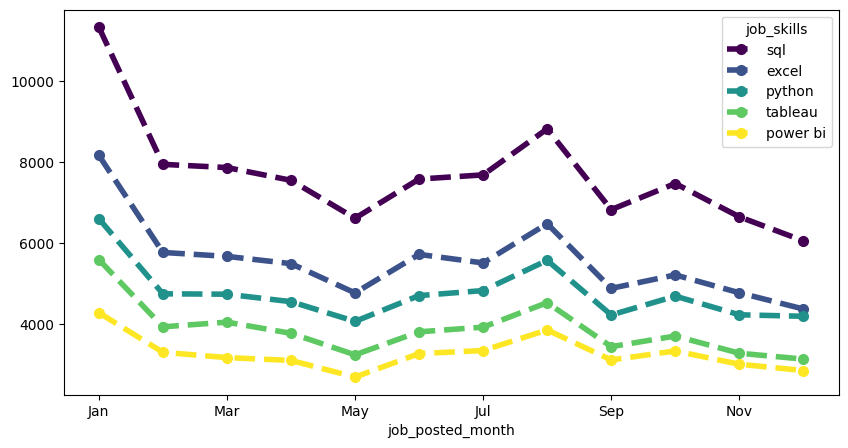

In [29]:
df_DA_pivot.iloc[:, :5].plot(
    kind="line",
    linewidth=4,
    linestyle="--", # options: "-", "--", "-.", ":"
    colormap="viridis", # options: "viridis", "plasma", "inferno", "magma", "cividis"
    marker="o", # options: "o", "x", "+", "*", "s", ",", ".", "1", "2", "3", "4", ...
    markersize=7,
    figsize=(10, 5)
)
plt.show()

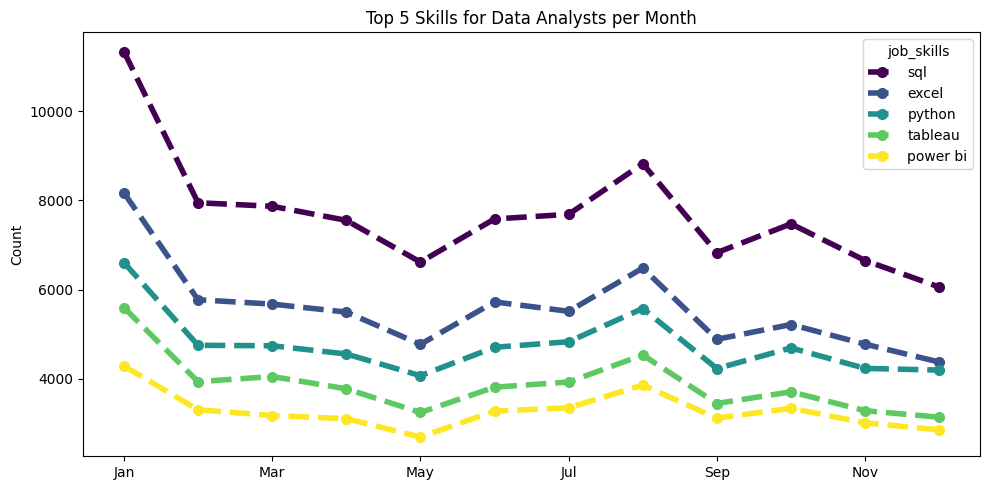

In [30]:
df_DA_pivot.iloc[:, :5].plot(
    kind="line",
    linewidth=4,
    linestyle="--", # options: "-", "--", "-.", ":"
    colormap="viridis", # options: "viridis", "plasma", "inferno", "magma", "cividis"
    marker="o", # options: "o", "x", "+", "*", "s", ",", ".", "1", "2", "3", "4", ...
    markersize=7,
    figsize=(10, 5)
)
plt.title("Top 5 Skills for Data Analysts per Month")
plt.ylabel("Count")
plt.xlabel("")
plt.tight_layout()
plt.show()

## Scatter plot customization

In [31]:
# Explode the "job_skills" into individual rows
df_exploded = df_DA.explode("job_skills")

# Calculate the average salary and count of job postings per skill
skill_stats = df_exploded.groupby("job_skills").agg(
    median_salary=("salary_year_avg", "median"),
    skill_count=("job_skills", "count")
)

# Limit to the top skills
skill_count = 20
skill_stats = skill_stats.sort_values(by="skill_count", ascending=False).head(skill_count)
skill_stats

,median_salary,skill_count
job_skills,,
sql,92500.000000,92428
excel,84479.000000,66860
python,98500.000000,57190
tableau,95000.000000,46455
power bi,90000.000000,39380
r,92527.500000,29996
sas,90000.000000,27998
powerpoint,85000.000000,13822
word,80000.000000,13562


<Axes: xlabel='skill_count', ylabel='median_salary'>

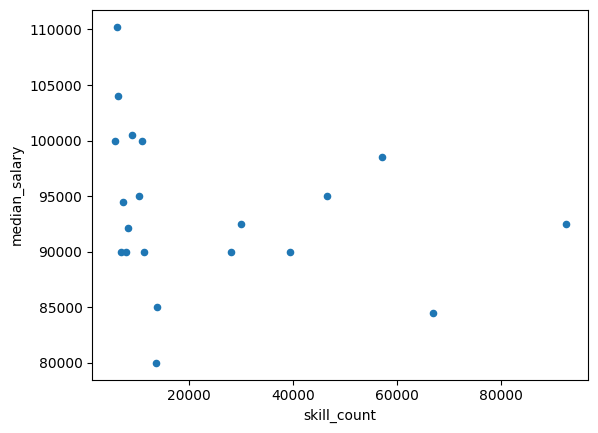

In [35]:
skill_stats.plot(kind="scatter", x="skill_count", y="median_salary")

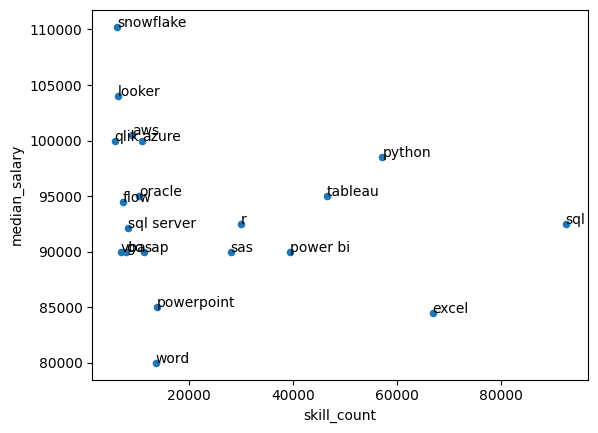

In [38]:
skill_stats.plot(kind="scatter", x="skill_count", y="median_salary")

for i, txt in enumerate(skill_stats.index):
    plt.text(skill_stats["skill_count"].iloc[i], skill_stats["median_salary"].iloc[i], txt)

In [37]:
!pip install adjustText


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


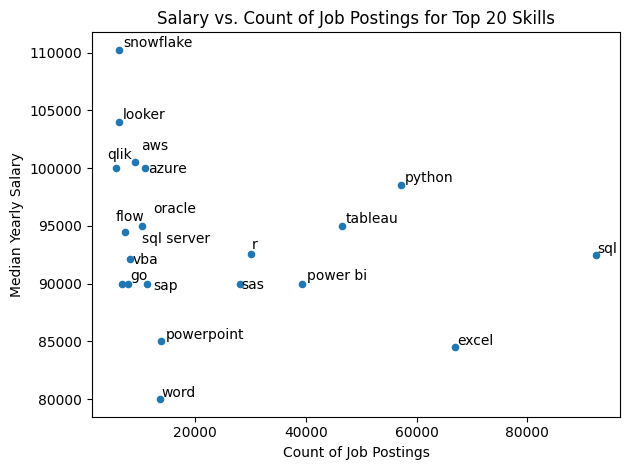

In [40]:
from adjustText import adjust_text

skill_stats.plot(kind="scatter", x="skill_count", y="median_salary")

texts = []
for i, txt in enumerate(skill_stats.index):
    texts.append(plt.text(skill_stats["skill_count"].iloc[i], skill_stats["median_salary"].iloc[i], txt))

adjust_text(texts)

plt.xlabel("Count of Job Postings")
plt.ylabel("Median Yearly Salary")
plt.title(f"Salary vs. Count of Job Postings for Top {skill_count} Skills")
plt.tight_layout()
plt.show()

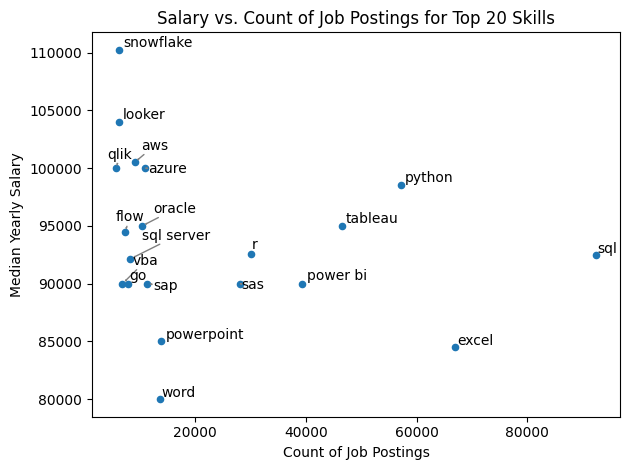

In [42]:
from adjustText import adjust_text

skill_stats.plot(kind="scatter", x="skill_count", y="median_salary")

texts = []
for i, txt in enumerate(skill_stats.index):
    texts.append(plt.text(skill_stats["skill_count"].iloc[i], skill_stats["median_salary"].iloc[i], txt))

adjust_text(texts, arrowprops=dict(arrowstyle="->", color="gray", lw=1))

plt.xlabel("Count of Job Postings")
plt.ylabel("Median Yearly Salary")
plt.title(f"Salary vs. Count of Job Postings for Top {skill_count} Skills")
plt.tight_layout()
plt.show()

### Modifying the y-axis labels

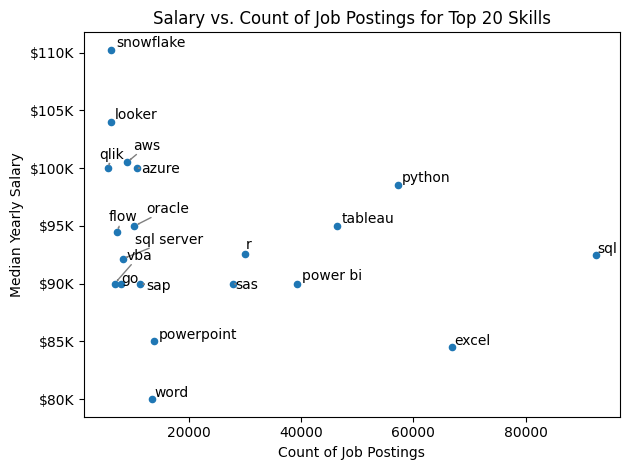

In [49]:
from adjustText import adjust_text


skill_stats.plot(kind="scatter", x="skill_count", y="median_salary")

texts = []
for i, txt in enumerate(skill_stats.index):
    texts.append(plt.text(skill_stats["skill_count"].iloc[i], skill_stats["median_salary"].iloc[i], txt))

adjust_text(texts, arrowprops=dict(arrowstyle="->", color="gray", lw=1))

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f"${int(y/1000)}K"))

plt.xlabel("Count of Job Postings")
plt.ylabel("Median Yearly Salary")
plt.title(f"Salary vs. Count of Job Postings for Top {skill_count} Skills")
plt.tight_layout()
plt.show()